# 02 — Train & Threshold

Trains the fraud-detection pipeline and selects an operating threshold. Loads raw data fresh; carries over conclusions from `01_eda.ipynb`, not data.

**Decisions from EDA:** Amount is right-skewed → log1p; fraud rate varies by
hour → derive Hour from Time; 0.17% imbalance → unsupervised model, stratified
split, PR-based evaluation.

1. Load `creditcard.csv`; slice raw columns (`V1–V28`, `Time`, `Amount`) into X.
2. Stratified train/test split (test_size=0.2, random_state=42).
3. Build the Pipeline so the transforms live inside it (ColumnTransformer: Time→Hour, Amount→log1p, passthrough V1–V28), then IsolationForest.
4. Fit on X_train (unsupervised, no y).
5. Threshold tuning: precision-recall over anomaly scores, 
6. Selecting an Operating point and model evaluation
    - Threshold locked at -0.12175: ~74.5% recall, ~8.95% precision, ~11:1 alert-to-fraud. Past this point, marginal recall
      costs a disproportionately larger review queue.
    - Model evaluation: PR-AUC (~0.2) which performs ~100x better than randomly guessing, ROC-AUC (~0.95)
7. Acceptance test: one raw row → score, confirming the transforms travel with the artifact.
8. Serialise to `model/artifacts/isolation_forest.pkl`.

In [114]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay, average_precision_score, roc_auc_score
from sklearn.utils import resample
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

### 1 & 2 - Load CSV data and create the train/test splits

In [101]:
# Load Data
df = pd.read_csv('../../data/creditcard.csv') 

In [102]:
# Stratified split
raw_cols = ["Time", "Amount"] + [f"V{i}" for i in range(1,29)]
X = df[raw_cols]
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 3 - Building the Pipeline

In [ ]:
# Building Pipeline
def secs_to_hour_of_day(x):
    '''Takes in raw seconds and returns the hour of day'''
    return (x % 86400) / 3600

time_transformer = FunctionTransformer(secs_to_hour_of_day, feature_names_out='one-to-one') 
#note: lambda doesn't work well with pickle
amount_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

column_transformations = ColumnTransformer(transformers=(
    ('time_to_hour_of_day', time_transformer,['Time']),
    ('amount_to_log', amount_transformer,['Amount'])),
    remainder = "passthrough"
    )

model = Pipeline([
    ('column_transformations', column_transformations),
    ('isolation_forest', IsolationForest(n_estimators=250, 
                                         max_samples=1024,
                                         contamination=0.0017, 
                                         random_state=42))
])


array([1, 1, 1, ..., 1, 1, 1], shape=(56962,))

### 4 - Fitting the model 

We fix on X_train. Since this is an unsupervised model and we are not labelling data, y is not involved in this step.

In [104]:
model.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('column_transformations', ...), ('isolation_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','Amount','V1',...,'V26','V27','V28']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('time_to_hour_of_day', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of column

### 5 - Threshold Tuning: 

In [105]:
y_score = -model.decision_function(X_test)


In [106]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_score)

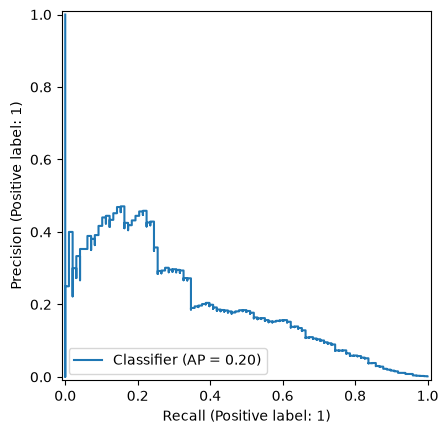

In [107]:
PrecisionRecallDisplay.from_predictions(
   y_test, y_score)

In [108]:
#thresholds[i] gives you approximately: precision[i], recall[i]
i = 40000
print(f"Threshold: {thresholds[i]}\nPrecision: {precision[i]}\nRecall: {recall[i]}")

Threshold: -0.2576249334668322
Precision: 0.00559890404431473
Recall: 0.9591836734693877


In [109]:
def calc_thresholds(target_recalls):
    """For each target recall, find the highest-precision operating point that
    still achieves at least that recall, and return the metrics as a DataFrame.

    Assumes `precision`, `recall`, `thresholds` are in scope from
    precision_recall_curve(...). Note precision/recall have one more element
    than thresholds, hence recall[:-1] to align indices.
    """
    rows = []
    seen = set()
    for target in target_recalls:
        valid = np.where(recall[:-1] >= target)[0]
        if len(valid) == 0:
            continue                      # no point reaches this recall

        best_idx = valid[np.argmax(precision[valid])]
        if best_idx in seen:
            continue                      # a different target hit this same point
        seen.add(best_idx)

        P = precision[best_idx]
        R = recall[best_idx]
        rows.append({
            "threshold":      round(thresholds[best_idx], 5),
            "recall":         round(R, 5),
            "precision":      round(P, 5),
            "alert_to_fraud": round(1 / P, 2),
            "f2":             round((5 * P * R) / (4 * P + R), 5),
        })

    return pd.DataFrame(rows)

In [110]:
calc_thresholds([i/100 for i in range(70,101,1)])


,threshold,recall,precision,alert_to_fraud,f2
0,-0.10641,0.70408,0.10376,9.64,0.32640
1,-0.10947,0.71429,0.10043,9.96,0.32140
2,-0.11451,0.72449,0.09543,10.48,0.31250
3,-0.11784,0.73469,0.09278,10.78,0.30822
4,-0.12175,0.74490,0.08946,11.18,0.30215
5,-0.13948,0.77551,0.07315,13.67,0.26555
6,-0.14791,0.78571,0.06498,15.39,0.24413
7,-0.15673,0.80612,0.05896,16.96,0.22806
8,-0.15930,0.81633,0.05739,17.42,0.22396
9,-0.16619,0.82653,0.05318,18.80,0.21149


### 6 - Selecting an operating point (threshold) and Model evaluation

**Selecting an operating point (threshold)**

My starting target was naive: 
1. Catch more than 80% of fraud
2. Keep the alert-to-fraud ratio near 10:1 (meaning roughly 10 flagged transactions for every genuine fraud caught). 

The precision-recall curve showed those two numbers don't coincide. A 10:1 ratio only happens around 70% recall, and getting recall above 80% pushes the ratio past 16:1. Catching more fraud means a bigger review queue, so the real job was picking a point on that trade-off, not hitting both targets at once.

I compared eight thresholds that gave a recall value between 70% and 80%, then narrowed my choices down to two:

| Metric | **-0.12175** (the knee) | **-0.13948** (past the knee) |
|---|---|---|
| Threshold | -0.12175 | -0.13948 |
| Recall | 74.5% | 77.6% |
| Frauds caught (of 98) | 73 | 76 |
| Precision | 8.95% | 7.32% |
| Alert-to-fraud ratio | 11.2:1 | 13.7:1 |
| Flags raised (~) | ~816 | ~1,040 |
| F2 | 0.302 | 0.266 |
| Position on curve | At the knee | Past the knee |
| Marginal cost of getting here | ~40–50 flags/fraud | ~74 flags/fraud |

I decided to go with the **-0.12175** threshold because it allowed me to catch (recall) ~74.5% of fraud, with an alert-to-fraud ratio of 11.2:1. The Precision value for this threshold is ~8.95%

Selecting the **-0.13948** threshold would mean reviewing ~28% more cases to catch 4% more fraud. 


In [115]:
pr_auc = average_precision_score(y_test, y_score)
pr_auc

0.20071497275009095

In [118]:
roc_auc = roc_auc_score(y_test, y_score)
roc_auc

0.9573710780035143

**Model evaluation**

ROC-AUC (Receiver Operating Characteristic, Area Under the Curve) measures how
well the model ranks fraud above non-fraud across all thresholds, scored 0 to 1.

This model scores ~0.95. That looks great by the usual standards, but it's
misleading here. With only 0.17% fraud, the false-positive rate barely moves
(there are so many legit transactions), so ROC-AUC stays high even when precision
is bad. PR-AUC tells the real story.

PR-AUC (Precision-Recall, Area Under the Curve) is also scored 0 to 1. Precision
is how many flagged transactions are actually fraud; recall is how many of the
real frauds we caught.

This model scores ~0.2. Looks low, but random guessing only scores ~0.0017 here
(the fraud rate), so ~0.2 is over 100x better than random.